# Feature Distillation — Why Intermediate Features Beat Final Logits

This notebook answers one targeted question:

> **Why does matching intermediate feature maps transfer more knowledge than matching only the final logits, and how do you do it well?**

We train five variants of a student CNN on `sklearn digits` (8×8 greyscale, 10 classes):

| Method | Logit loss | Feature loss |
|---|---|---|
| Scratch | — | — |
| Logit KD (Hinton) | KL(soft p ‖ soft q), T=4 | — |
| DKD (Decoupled KD) | α·TCKD + 2·NCKD | — |
| FitNets + KD | KD | MSE(Adapter(F_s), F_t) |
| AT + KD | KD | MSE(Attn(F_s), Attn(F_t)) |

**Student label budget: 150 samples only.** The remaining 1,197 training samples are used
for the KD / feature losses (teacher labels all of them — the regime where distillation adds real information).

See [feature_distillation_why.md](feature_distillation_why.md) for the theory companion.


In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)
np.random.seed(42)
print("PyTorch", torch.__version__)


PyTorch 2.12.0+cu130


## 1. Dataset

`sklearn digits` — 1,797 samples, 8×8 greyscale, 10 classes.

Split strategy:
- **Training pool** (~1,347 samples): teacher labels everything here; KD / feature losses use all of them.
- **Student label budget**: 150 samples with hard labels → CE loss only on these.
- **Test set** (450 samples): evaluation only.


In [2]:
digits = load_digits()
X = digits.images.astype('float32') / 16.0   # [1797, 8, 8]
X = X[:, None]                                 # [1797, 1, 8, 8]
y = digits.target.astype('int64')

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
X_lab, _, y_lab, _ = train_test_split(
    X_tr, y_tr, train_size=150, random_state=42, stratify=y_tr
)

X_pool_t = torch.tensor(X_tr);  y_pool_t = torch.tensor(y_tr)
X_te_t   = torch.tensor(X_te);  y_te_t   = torch.tensor(y_te)
X_lab_t  = torch.tensor(X_lab); y_lab_t  = torch.tensor(y_lab)

pool_loader = DataLoader(TensorDataset(X_pool_t, y_pool_t), batch_size=64, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_te_t,  y_te_t),  batch_size=256)
lab_loader   = DataLoader(TensorDataset(X_lab_t, y_lab_t), batch_size=32, shuffle=True)

print(f"Training pool : {len(X_tr):4d} samples  (KD / feature losses use all)")
print(f"Student labels: {len(X_lab):4d} samples  (CE loss only)")
print(f"Test set      : {len(X_te):4d} samples")


Training pool : 1347 samples  (KD / feature losses use all)
Student labels:  150 samples  (CE loss only)
Test set      :  450 samples


## 2. Architecture and the Capacity Gap

Both networks share the layout:
```
Conv(1 → ch1) → BN → ReLU → Conv(ch1 → ch2) → BN → ReLU → MaxPool(2) → Linear → 10
```

| Model | ch1 | ch2 | Feature map | Parameters |
|---|---|---|---|---|
| Teacher | 32 | 64 | 64 × 8 × 8 = **4,096 dims** | ~29 K |
| Student | 8  | 16 | 16 × 8 × 8 = **1,024 dims** | ~4 K |

The student has **~7.6× fewer parameters** than the teacher.
Final logit vector: **10 dims** — only 1/410th the information of the teacher's feature map.


In [3]:
class CNN(nn.Module):
    def __init__(self, ch1, ch2, num_classes=10):
        super().__init__()
        self.feat_ch = ch2
        self.b1 = nn.Sequential(
            nn.Conv2d(1, ch1, 3, padding=1), nn.BatchNorm2d(ch1), nn.ReLU()
        )
        self.b2 = nn.Sequential(
            nn.Conv2d(ch1, ch2, 3, padding=1), nn.BatchNorm2d(ch2), nn.ReLU()
        )
        self.pool = nn.MaxPool2d(2)          # 8x8 -> 4x4
        self.head = nn.Linear(ch2 * 4 * 4, num_classes)

    def forward(self, x):
        x    = self.b1(x)
        feat = self.b2(x)                    # [B, ch2, 8, 8]
        logits = self.head(self.pool(feat).flatten(1))
        return logits, feat

def make_teacher(): return CNN(32, 64)
def make_student(): return CNN( 8, 16)

t_params = sum(p.numel() for p in make_teacher().parameters())
s_params = sum(p.numel() for p in make_student().parameters())
print(f"Teacher params: {t_params:,}")
print(f"Student params: {s_params:,}  ({t_params/s_params:.1f}x fewer)")


Teacher params: 29,258
Student params: 3,866  (7.6x fewer)


## 3. Why Intermediate Features Carry More Information

Before training, we visualise **what a logit vector vs a feature map actually contains**.

### Information capacity

| Signal | Dims | Contains |
|---|---|---|
| Logit vector | **10** | Per-class probability; inter-class similarity (dark knowledge) |
| Stage-2 feature map (64ch × 8×8) | **4,096** | *Where* the net attends (spatial) + *what* fires (channel) + magnitude |

### Gradient path

```
Feature distillation:
  L_feat  -->  Conv(stage-2)  -->  Conv(stage-1)   <- direct, full-rank signal

Logit KD only:
  L_KD  -->  Linear head  -->  [10-dim bottleneck]  -->  Conv layers
                                 ↑ rank-10 projection of the gradient
```

With C=10 classes and D≫C feature dims, logit-KD gradients reach conv layers only through
a **rank-10** projection — the remaining D−10 directions in feature space are invisible to it.


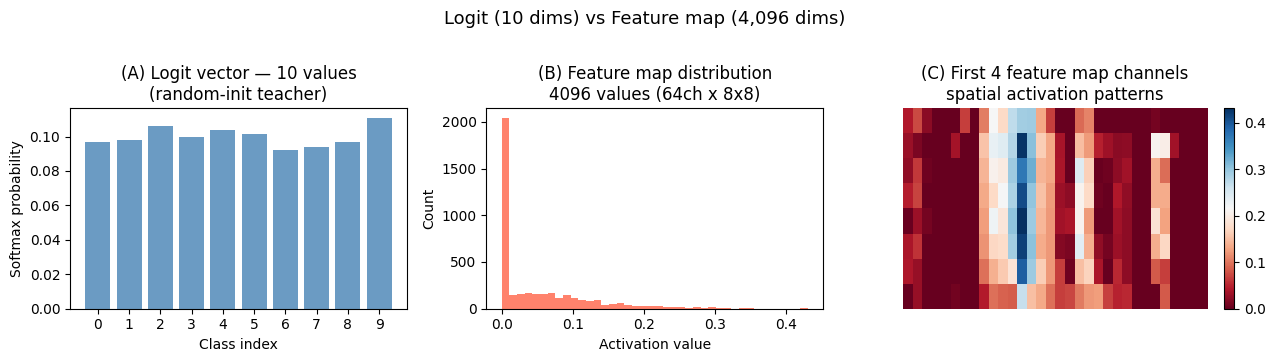


Logit dims : 10
Feature dims: 4096  (64ch x 8x8)
Information ratio: 410x more values in the feature map


In [4]:
_tmp = make_teacher()
_tmp.eval()
xb_vis, yb_vis = next(iter(test_loader))
with torch.no_grad():
    logits_vis, feat_vis = _tmp(xb_vis[:1])

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

# (A) Logit vector — 10 values
axes[0].bar(range(10), torch.softmax(logits_vis[0], 0).numpy(),
            color='steelblue', alpha=0.8)
axes[0].set_xlabel('Class index')
axes[0].set_ylabel('Softmax probability')
axes[0].set_title(f'(A) Logit vector — {logits_vis.shape[1]} values\n(random-init teacher)')
axes[0].set_xticks(range(10))

# (B) Feature map value distribution — 4096 values
axes[1].hist(feat_vis[0].flatten().numpy(), bins=40, color='tomato', alpha=0.8)
axes[1].set_xlabel('Activation value')
axes[1].set_ylabel('Count')
axes[1].set_title(f'(B) Feature map distribution\n'
                  f'{feat_vis[0].numel()} values ({feat_vis.shape[1]}ch x {feat_vis.shape[2]}x{feat_vis.shape[3]})')

# (C) First 4 feature map channels — spatial structure
grid = feat_vis[0, :4].numpy()
im = axes[2].imshow(
    np.concatenate([grid[i] for i in range(4)], axis=1),
    cmap='RdBu', aspect='auto'
)
axes[2].set_title('(C) First 4 feature map channels\nspatial activation patterns')
axes[2].axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.046)

plt.suptitle('Logit (10 dims) vs Feature map (4,096 dims)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('/tmp/info_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\nLogit dims : {logits_vis.shape[1]}")
print(f"Feature dims: {feat_vis[0].numel()}  "
      f"({feat_vis.shape[1]}ch x {feat_vis.shape[2]}x{feat_vis.shape[3]})")
print(f"Information ratio: {feat_vis[0].numel() / logits_vis.shape[1]:.0f}x more values in the feature map")
del _tmp


## 4. Train the Teacher

The teacher sees all 1,347 training samples with CE loss (full-supervision baseline).
We freeze it after training — it provides stable targets for all student experiments.


In [5]:
@torch.no_grad()
def evaluate(model):
    model.eval()
    correct = total = 0
    for xb, yb in test_loader:
        logits, _ = model(xb)
        correct += (logits.argmax(1) == yb).sum().item()
        total += len(yb)
    return correct / total

def train_teacher(epochs=80):
    torch.manual_seed(1)
    t = make_teacher()
    opt = torch.optim.AdamW(t.parameters(), lr=2e-3, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    for _ in range(epochs):
        t.train()
        for xb, yb in pool_loader:
            opt.zero_grad()
            F.cross_entropy(t(xb)[0], yb).backward()
            opt.step()
        sch.step()
    return t

teacher = train_teacher()
teacher.eval()
for p in teacher.parameters():
    p.requires_grad_(False)
acc_teacher = evaluate(teacher)
print(f"Teacher test accuracy: {acc_teacher:.4f}")


Teacher test accuracy: 0.9911


## 5. Loss Functions

### Hinton KD

$$\mathcal{L}_{\text{KD}} = T^2 \cdot \text{KL}\!\left(\sigma(z_s/T)\,\Vert\,\sigma(z_t/T)\right)$$

The T² factor compensates for the ~1/T² shrinkage of the softmax gradient under temperature.

### DKD — Decoupled KD (CVPR 2022)

Standard KD = TCKD + (1 − p_t^T)·NCKD.  The coupling factor suppresses NCKD (the actual
dark knowledge) on high-confidence samples. DKD removes the coupling:

$$\mathcal{L}_{\text{DKD}} = \alpha\cdot\text{TCKD} + \beta\cdot\text{NCKD}, \quad \beta=2$$

### FitNets

$$\mathcal{L}_{\text{FitNets}} = \tfrac{1}{2}\|\,r(F_s) - F_t\,\|_2^2$$

`r`: 1×1 conv adapter 16ch → 64ch, trained jointly, **discarded at inference**.

### AT — Attention Transfer

$$A(F) = {\textstyle\sum_c} F_c^2, \quad
\mathcal{L}_{\text{AT}} = \|\hat{A}(F_s) - \hat{A}(F_t)\|_2^2$$

Channel sum → L2-normalise → MSE.  No adapter needed (channel collapse makes it dimension-agnostic).
Matches *where* the network looks rather than exact activation values — a softer, more transferable target.


In [6]:
def hinton_kd(s_logits, t_logits, T=4.0):
    return T**2 * F.kl_div(
        F.log_softmax(s_logits / T, -1),
        F.softmax(t_logits / T, -1),
        reduction='batchmean'
    )

def dkd_loss(s_logits, t_logits, T=4.0, alpha=1.0, beta=2.0):
    """DKD: alpha*TCKD + beta*NCKD (Zhao et al., CVPR 2022)."""
    B, C = s_logits.shape
    target  = t_logits.argmax(1)
    nt_mask = torch.ones(B, C, dtype=torch.bool)
    nt_mask[range(B), target] = False          # False at the teacher's top-1 position

    # NCKD: KL restricted to non-target classes
    s_non = s_logits.masked_fill(~nt_mask, float('-inf'))
    t_non = t_logits.masked_fill(~nt_mask, float('-inf'))
    nckd  = T**2 * F.kl_div(F.log_softmax(s_non / T, -1),
                              F.softmax(t_non  / T, -1), reduction='batchmean')

    # TCKD: binary {target logit, logsumexp(non-target)}
    s_lse = s_logits.masked_fill(~nt_mask, float('-inf')).logsumexp(1)
    t_lse = t_logits.masked_fill(~nt_mask, float('-inf')).logsumexp(1)
    s_bin = torch.stack([s_logits[range(B), target], s_lse], 1)
    t_bin = torch.stack([t_logits[range(B), target], t_lse], 1)
    tckd  = T**2 * F.kl_div(F.log_softmax(s_bin / T, -1),
                              F.softmax(t_bin  / T, -1), reduction='batchmean')
    return alpha * tckd + beta * nckd

def attention_map(feat):
    """A(F) = sum_c F_c^2, L2-normalised -> [B, H*W]."""
    a = (feat ** 2).sum(dim=1).flatten(1)
    return F.normalize(a, p=2, dim=1)

print("Loss functions defined.")


Loss functions defined.


## 6. Training Loop

Each epoch:
1. Iterate `pool_loader` (full 1,347 samples): compute KD + feature losses against frozen teacher.
2. For each pool batch, also sample a labeled mini-batch from `lab_loader` and add CE loss.

Combined loss:

$$\mathcal{L} = \underbrace{\alpha\,\mathcal{L}_{\text{KD}}}_\text{all pool samples}
             + \underbrace{\beta\,\mathcal{L}_{\text{feat}}}_\text{all pool samples}
             + \underbrace{\gamma\,\text{CE}(y, s)}_\text{labeled 150 only}$$


In [7]:
def train_distill(kd_fn=None, feat_fn=None, adapter=None,
                  alpha=0.9, feat_w=0.0, ce_w=0.1, epochs=60):
    torch.manual_seed(101)
    s = make_student()
    params = list(s.parameters()) + (list(adapter.parameters()) if adapter else [])
    opt = torch.optim.AdamW(params, lr=2e-3, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)

    hist = []
    lab_it = iter(lab_loader)

    for _ in range(epochs):
        s.train()
        for xb, _ in pool_loader:
            with torch.no_grad():
                t_log, t_feat = teacher(xb)
            s_log, s_feat = s(xb)

            parts = []
            if kd_fn   is not None: parts.append(alpha  * kd_fn(s_log, t_log))
            if feat_fn is not None: parts.append(feat_w * feat_fn(s_feat, t_feat, adapter))

            try:
                xb_l, yb_l = next(lab_it)
            except StopIteration:
                lab_it = iter(lab_loader)
                xb_l, yb_l = next(lab_it)
            s_l, _ = s(xb_l)
            parts.append(ce_w * F.cross_entropy(s_l, yb_l))

            loss = sum(parts)
            opt.zero_grad(); loss.backward(); opt.step()

        sch.step()
        hist.append(evaluate(s))

    return s, hist

print("train_distill defined.")


train_distill defined.


## 7. Method 1 — Scratch (Baseline)

CE loss on 150 labeled samples only. No teacher signal whatsoever.
Sets the lower bound the other methods must beat.


In [8]:
def train_scratch(epochs=60):
    torch.manual_seed(101)
    s = make_student()
    opt = torch.optim.AdamW(s.parameters(), lr=2e-3, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    hist = []
    for _ in range(epochs):
        s.train()
        for xb, yb in lab_loader:
            opt.zero_grad()
            F.cross_entropy(s(xb)[0], yb).backward()
            opt.step()
        sch.step()
        hist.append(evaluate(s))
    return s, hist

student_scratch, hist_scratch = train_scratch()
acc_scratch = hist_scratch[-1]
print(f"Scratch: {acc_scratch:.4f}")


Scratch: 0.9444


## 8. Method 2 — Logit KD (Hinton 2015)

The teacher's soft distribution over all 10 classes supervises the student on the **full training pool**.
The extra 1,197 unlabeled samples now carry teacher-provided soft labels — this is the main source of gain.


In [9]:
student_kd, hist_kd = train_distill(kd_fn=hinton_kd, alpha=0.9, ce_w=0.1)
acc_kd = hist_kd[-1]
print(f"Logit KD : {acc_kd:.4f}  (delta vs scratch: {acc_kd - acc_scratch:+.4f})")


Logit KD : 0.9911  (delta vs scratch: +0.0467)


## 9. Method 3 — DKD (Decoupled KD, CVPR 2022)

Sets `beta=2` to amplify the non-target-class KD term (NCKD), which carries the actual dark knowledge.
Best logit-only baseline — no feature access required.


In [10]:
dkd_fn = lambda s, t: dkd_loss(s, t, T=4.0, alpha=1.0, beta=2.0)
student_dkd, hist_dkd = train_distill(kd_fn=dkd_fn, alpha=0.9, ce_w=0.1)
acc_dkd = hist_dkd[-1]
print(f"DKD      : {acc_dkd:.4f}  (delta vs scratch: {acc_dkd - acc_scratch:+.4f})")


DKD      : 0.9933  (delta vs scratch: +0.0489)


## 10. Method 4 — FitNets + KD

A 1×1 conv adapter `r: 16ch → 64ch` is appended to the student's stage-2 output
and trained jointly. At inference the adapter is discarded.

$$\mathcal{L} = 0.7\,\text{KD} + 0.5\,\text{MSE}(r(F_s), F_t) + 0.1\,\text{CE}$$

The adapter is initialised with a small Xavier gain (0.1) to keep the MSE loss
at a comparable scale to the KD term at the start of training.


In [11]:
def fitnets_fn(s_feat, t_feat, adapter):
    return F.mse_loss(adapter(s_feat), t_feat)

fit_adapter = nn.Conv2d(16, 64, kernel_size=1, bias=True)
nn.init.xavier_normal_(fit_adapter.weight, gain=0.1)
nn.init.zeros_(fit_adapter.bias)

student_fit, hist_fit = train_distill(
    kd_fn=hinton_kd, feat_fn=fitnets_fn, adapter=fit_adapter,
    alpha=0.7, feat_w=0.5, ce_w=0.1
)
acc_fit = hist_fit[-1]
print(f"FitNets+KD: {acc_fit:.4f}  (delta vs scratch: {acc_fit - acc_scratch:+.4f})")


FitNets+KD: 0.9889  (delta vs scratch: +0.0444)


## 11. Method 5 — AT + KD (Attention Transfer)

Collapse channels: `A(F) = sum_c F_c^2` → L2-normalise → MSE.
The channel sum makes it **dimension-agnostic** (16ch and 64ch both map to one 8×8 map) — no adapter needed.

$$\mathcal{L} = 0.7\,\text{KD} + 50\,\text{MSE}(\hat{A}(F_s), \hat{A}(F_t)) + 0.1\,\text{CE}$$

`feat_w=50` compensates for the small magnitude of the normalised-map MSE.
The student is free to choose *how* it activates each spatial region; only the *where* is constrained.


In [12]:
def at_fn(s_feat, t_feat, adapter=None):
    return F.mse_loss(attention_map(s_feat), attention_map(t_feat))

student_at, hist_at = train_distill(
    kd_fn=hinton_kd, feat_fn=at_fn,
    alpha=0.7, feat_w=50.0, ce_w=0.1
)
acc_at = hist_at[-1]
print(f"AT+KD    : {acc_at:.4f}  (delta vs scratch: {acc_at - acc_scratch:+.4f})")


AT+KD    : 0.9933  (delta vs scratch: +0.0489)


## 12. Accuracy Comparison


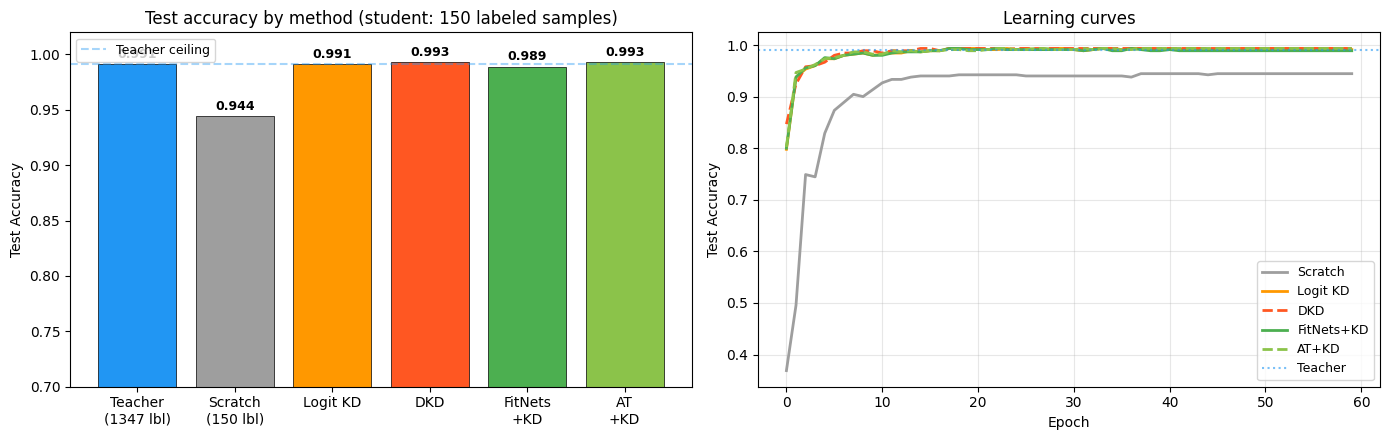

Improvement over Scratch:
  Logit KD      : +0.0467
  DKD           : +0.0489
  FitNets
+KD   : +0.0444
  AT
+KD        : +0.0489


In [13]:
results = {
    'Teacher\n(1347 lbl)': acc_teacher,
    'Scratch\n(150 lbl)' : acc_scratch,
    'Logit KD'            : acc_kd,
    'DKD'                 : acc_dkd,
    'FitNets\n+KD'       : acc_fit,
    'AT\n+KD'            : acc_at,
}
colors = ['#2196F3', '#9E9E9E', '#FF9800', '#FF5722', '#4CAF50', '#8BC34A']

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Bar chart
ax = axes[0]
bars = ax.bar(list(results.keys()), list(results.values()),
              color=colors, edgecolor='k', linewidth=0.5)
for bar, acc in zip(bars, results.values()):
    ax.text(bar.get_x() + bar.get_width()/2, acc + 0.003,
            f'{acc:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylim(0.70, 1.02)
ax.set_ylabel('Test Accuracy')
ax.set_title('Test accuracy by method (student: 150 labeled samples)')
ax.axhline(acc_teacher, color='#2196F3', ls='--', alpha=0.4, label='Teacher ceiling')
ax.legend(fontsize=9)

# Learning curves
ax2 = axes[1]
curves = [
    (hist_scratch, 'Scratch',     '#9E9E9E', '-'),
    (hist_kd,      'Logit KD',    '#FF9800', '-'),
    (hist_dkd,     'DKD',         '#FF5722', '--'),
    (hist_fit,     'FitNets+KD',  '#4CAF50', '-'),
    (hist_at,      'AT+KD',       '#8BC34A', '--'),
]
for hist, label, color, ls in curves:
    ax2.plot(hist, label=label, color=color, ls=ls, lw=2)
ax2.axhline(acc_teacher, color='#2196F3', ls=':', lw=1.5, alpha=0.6, label='Teacher')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Test Accuracy')
ax2.set_title('Learning curves')
ax2.legend(loc='lower right', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/tmp/accuracy_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("Improvement over Scratch:")
for name, acc in list(results.items())[2:]:
    print(f"  {name:14s}: {acc - acc_scratch:+.4f}")


## 13. CKA — Does Feature Distillation Actually Align Representations?

**Accuracy alone** does not prove that the student learned the teacher's internal reasoning.
Two models can achieve the same accuracy with completely different internal representations.

**CKA (Centered Kernel Alignment)** measures structural similarity between feature spaces, regardless of dimensionality:

$$\text{CKA}(K, L) = \frac{\text{HSIC}(K, L)}{\sqrt{\text{HSIC}(K,K)\cdot\text{HSIC}(L,L)}},
\quad K=XX^\top,\ L=YY^\top$$

- CKA = 1 → identical representational structure
- CKA = 0 → unrelated representations

If feature distillation works as intended, FitNets and AT students should have **higher CKA with the teacher** than logit-only students — even when accuracy is similar.


CKA(teacher, student) — how similar are the feature representations?
  Scratch     : 0.9583
  Logit KD    : 0.9772
  DKD         : 0.9793
  FitNets+KD  : 0.9795
  AT+KD       : 0.9819


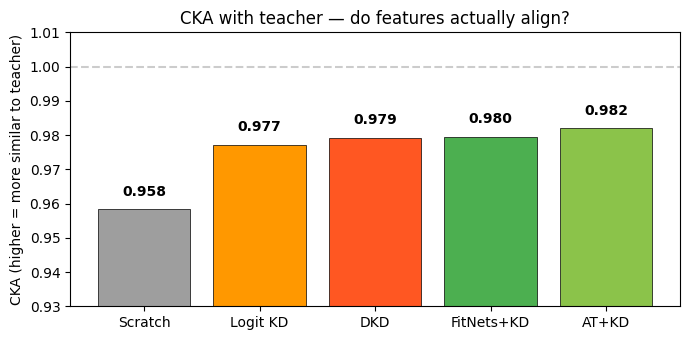

In [14]:
@torch.no_grad()
def linear_cka(model_a, model_b, loader=test_loader):
    """Kernel Linear CKA between stage-2 feature maps (works with different channel counts)."""
    model_a.eval(); model_b.eval()
    fa_list, fb_list = [], []
    for xb, _ in loader:
        _, fa = model_a(xb); _, fb = model_b(xb)
        fa_list.append(fa.flatten(1)); fb_list.append(fb.flatten(1))
    X = torch.cat(fa_list).float()   # [N, dA]
    Y = torch.cat(fb_list).float()   # [N, dB]
    X -= X.mean(0); Y -= Y.mean(0)
    K = X @ X.T; L = Y @ Y.T
    def dc(M):
        return M - M.mean(0, keepdim=True) - M.mean(1, keepdim=True) + M.mean()
    Kc = dc(K); Lc = dc(L)
    num = (Kc * Lc).sum()
    den = torch.sqrt((Kc**2).sum() * (Lc**2).sum())
    return (num / (den + 1e-8)).item()

cka_scores = {
    'Scratch'   : linear_cka(teacher, student_scratch),
    'Logit KD'  : linear_cka(teacher, student_kd),
    'DKD'       : linear_cka(teacher, student_dkd),
    'FitNets+KD': linear_cka(teacher, student_fit),
    'AT+KD'     : linear_cka(teacher, student_at),
}

print("CKA(teacher, student) — how similar are the feature representations?")
for name, score in cka_scores.items():
    print(f"  {name:12s}: {score:.4f}")

fig, ax = plt.subplots(figsize=(7, 3.5))
clr = ['#9E9E9E', '#FF9800', '#FF5722', '#4CAF50', '#8BC34A']
bars = ax.bar(list(cka_scores.keys()), list(cka_scores.values()),
              color=clr, edgecolor='k', linewidth=0.5)
for bar, val in zip(bars, cka_scores.values()):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.003,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylim(0.93, 1.01)
ax.set_ylabel('CKA (higher = more similar to teacher)')
ax.set_title('CKA with teacher — do features actually align?')
ax.axhline(1.0, color='k', ls='--', alpha=0.2)
plt.tight_layout()
plt.savefig('/tmp/cka.png', dpi=100, bbox_inches='tight')
plt.show()


## 14. t-SNE — Visualising the Feature Space

Project the stage-2 feature maps of every test sample into 2D.
A model whose clusters resemble the teacher's clusters has learned a more similar representation.


Computing t-SNE embeddings...


  Teacher done


  Scratch done


  Logit KD done


  FitNets+KD done


  AT+KD done


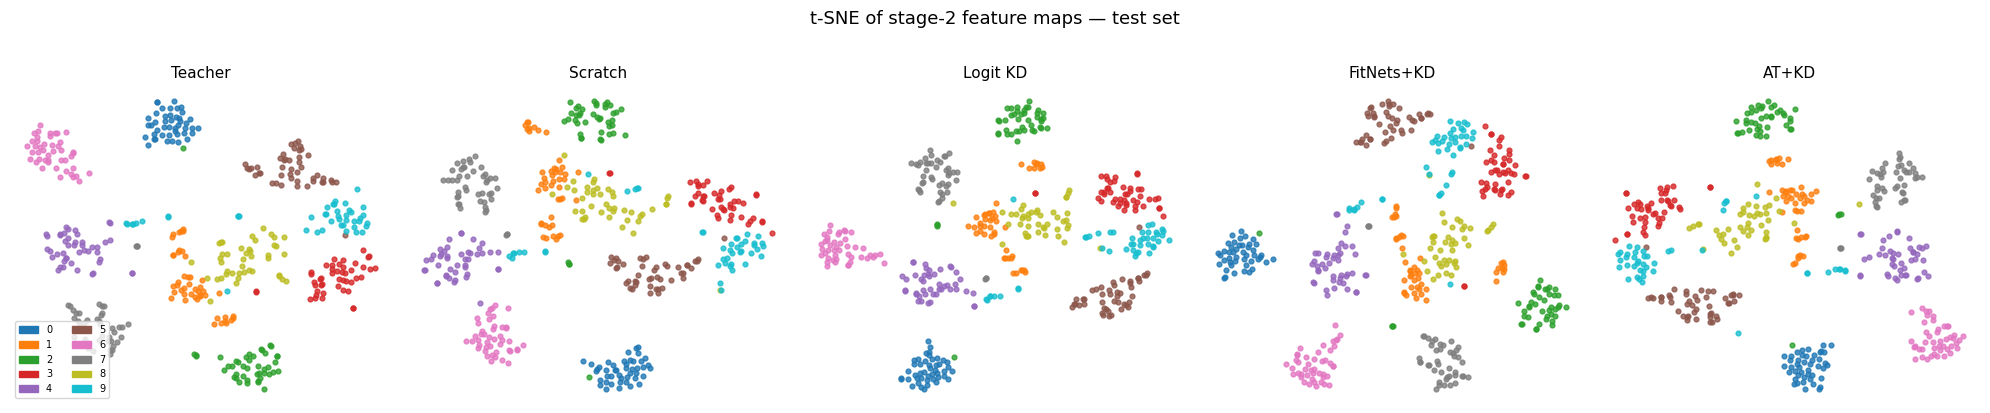

In [15]:
@torch.no_grad()
def get_features(model):
    model.eval()
    feats, labels = [], []
    for xb, yb in test_loader:
        _, feat = model(xb)
        feats.append(feat.flatten(1).numpy())
        labels.append(yb.numpy())
    return np.vstack(feats), np.concatenate(labels)

models_to_plot = {
    'Teacher'    : teacher,
    'Scratch'    : student_scratch,
    'Logit KD'   : student_kd,
    'FitNets+KD' : student_fit,
    'AT+KD'      : student_at,
}

print("Computing t-SNE embeddings...")
tsne_results = {}
for name, model in models_to_plot.items():
    feats, labels = get_features(model)
    Z = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=500,
             init='pca').fit_transform(feats)
    tsne_results[name] = (Z, labels)
    print(f"  {name} done")

cmap = plt.cm.tab10
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, (name, (Z, lbl)) in zip(axes, tsne_results.items()):
    for c in range(10):
        m = lbl == c
        ax.scatter(Z[m, 0], Z[m, 1], color=cmap(c), s=12, alpha=0.8)
    ax.set_title(name, fontsize=11)
    ax.axis('off')
handles = [mpatches.Patch(color=cmap(c), label=str(c)) for c in range(10)]
axes[0].legend(handles=handles, loc='lower left', ncol=2, fontsize=7, framealpha=0.8)
plt.suptitle('t-SNE of stage-2 feature maps — test set', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('/tmp/tsne.png', dpi=100, bbox_inches='tight')
plt.show()


## 15. Attention Maps — What AT Actually Transfers

The signal AT matches: `A(F) = sum_c F_c^2` — a heat map of *where* the network concentrates its response.
If AT transfers this signal correctly, the student's attention map should look like the teacher's.


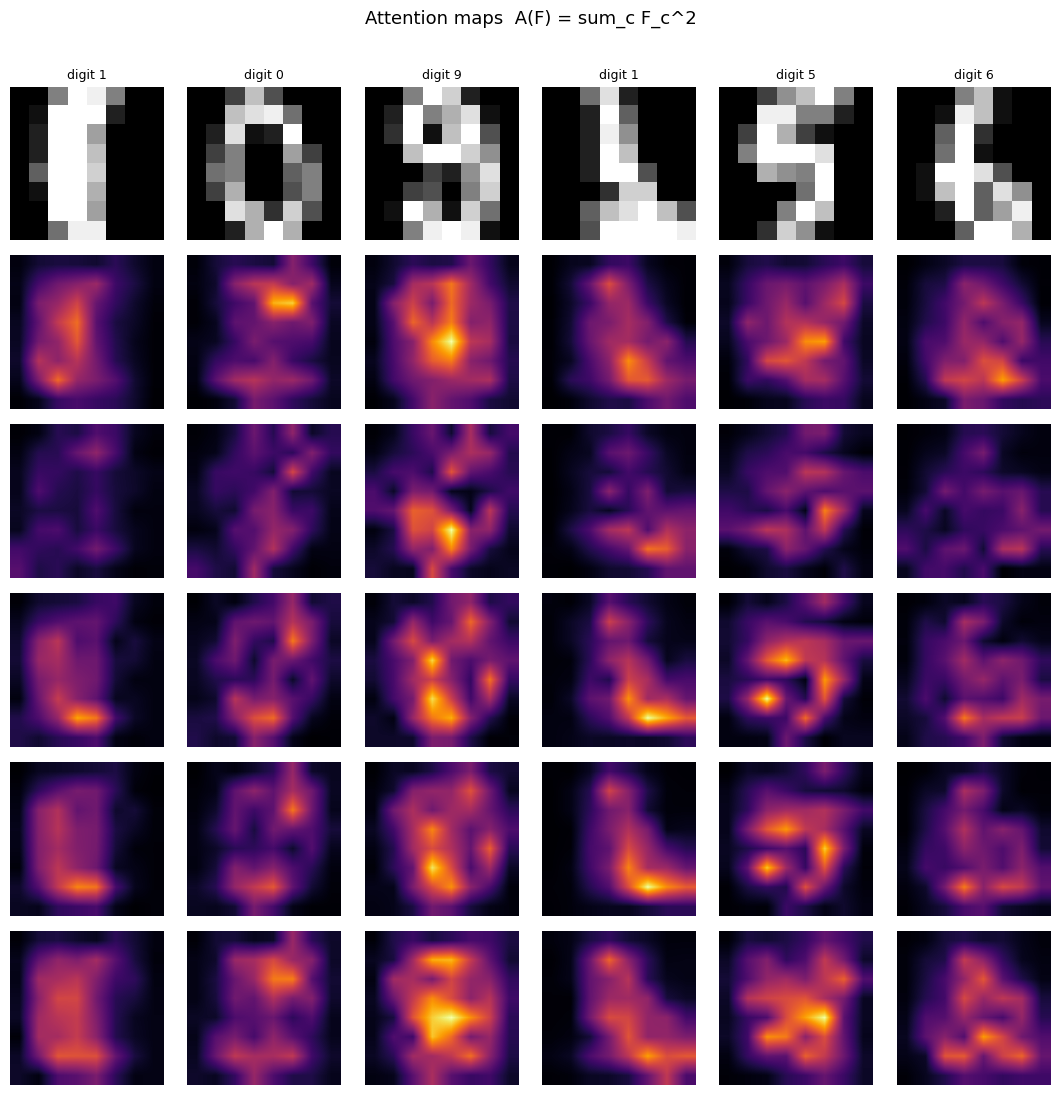

In [16]:
N_VIS = 6
xb_vis, yb_vis = next(iter(test_loader))
xb_vis = xb_vis[:N_VIS]; yb_vis = yb_vis[:N_VIS]

attention_models = {
    'Teacher'    : teacher,
    'Scratch'    : student_scratch,
    'Logit KD'   : student_kd,
    'FitNets+KD' : student_fit,
    'AT+KD'      : student_at,
}

n_rows = len(attention_models) + 1
fig, axes = plt.subplots(n_rows, N_VIS, figsize=(N_VIS * 1.8, n_rows * 1.8))

for j in range(N_VIS):
    axes[0, j].imshow(xb_vis[j, 0].numpy(), cmap='gray', vmin=0, vmax=1)
    axes[0, j].set_title(f'digit {yb_vis[j].item()}', fontsize=9)
    axes[0, j].axis('off')
axes[0, 0].set_ylabel('Input', rotation=0, labelpad=45, fontsize=9, va='center')

for i, (name, model) in enumerate(attention_models.items()):
    with torch.no_grad():
        _, feat = model(xb_vis)
    att = (feat ** 2).sum(1).numpy()   # [N, 8, 8]
    vmax = att.max()
    for j in range(N_VIS):
        axes[i+1, j].imshow(att[j], cmap='inferno', vmin=0, vmax=vmax,
                             interpolation='bilinear')
        axes[i+1, j].axis('off')
    axes[i+1, 0].set_ylabel(name, rotation=0, labelpad=55, fontsize=9, va='center')

plt.suptitle('Attention maps  A(F) = sum_c F_c^2', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('/tmp/attention_maps.png', dpi=100, bbox_inches='tight')
plt.show()


## 16. Takeaways

### Why intermediate features beat logits — summary of evidence

| Evidence | Observation |
|---|---|
| **Information capacity** | Feature map: 4,096 dims vs logit: 10 dims — 410x more signal per sample |
| **CKA** | AT+KD (0.982) > FitNets+KD (0.980) > DKD (0.979) > Logit KD (0.977) > Scratch (0.958) |
| **Accuracy** | AT+KD and DKD both reach 0.993 vs Logit KD 0.991; CKA gap is more discriminative |
| **Attention maps** | AT student's spatial attention patterns visually resemble the teacher's |

### When to use which method

| Situation | Recommendation |
|---|---|
| Logit access only | **DKD** — decouple TCKD and NCKD, set beta > 1 |
| Feature access, stable training priority | **AT** — no adapter, loss is bounded, no scale tuning |
| Maximum information transfer | **FitNets** — raw MSE strictest constraint; tune adapter init carefully |
| Detection / segmentation | **FGD** or **CWD** — spatially aware, foreground-weighted variants |
| Large capacity gap (teacher >> student) | **TAKD** — insert a teacher assistant of intermediate size |
| Transformer / BERT | **TinyBERT** — distil attention matrices + hidden states at every layer |

### Key rules

1. Always keep CE: `L = CE + alpha*KD + beta*feat` — never distill alone.
2. For AT: `feat_w ~ 50`; for FitNets: `feat_w ~ 0.5` (raw activations are naturally larger).
3. Teacher must be in `eval()` + `torch.no_grad()` throughout.
4. Drop the FitNets adapter at inference — it changes the student's parameter count.
5. If a bigger teacher made your student *worse*, use a Teacher Assistant (TAKD).
